# Ingredient CO₂e Matching — Visualizations

**Pipeline overview:**
1. `recipe_ingredients.csv` holds raw ingredient names with free-text quantities.
2. `main.ipynb` tries to match every unique ingredient to a CO₂e value:
   - **Wolfram (direct)** — ingredient name is already in the Wolfram Alpha food carbon dataset.
   - **Wolfram (manual alias)** — a hand-crafted map translates the recipe name → Wolfram clean name.
   - **OWID fallback** — if Wolfram fails, a second map resolves the ingredient to an [Our World In Data](https://ourworldindata.org/) entity.
   - **Unmatched** — no CO₂e value could be assigned.
3. Matched values are saved to `ingredient_co2.csv`.

These charts expose every step: what was matched, how, and what was left out.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

os.makedirs('figures', exist_ok=True)
plt.rcParams.update({'figure.dpi': 150, 'font.size': 10})

COLORS = {
    'Wolfram (direct)':       '#2E86AB',
    'Wolfram (manual alias)': '#A23B72',
    'OWID fallback':          '#F18F01',
    'Unmatched':              '#C73E1D',
}

# ── Load data ──────────────────────────────────────────────────────────────────
ingr_df = pd.read_csv('../preprocessing/recipe_ingredients.csv')
co2_df  = pd.read_csv('../preprocessing/ingredient_co2.csv')
carbon  = pd.read_excel('../preprocessing/Wolfram_Food_Carbon_Footprint.xlsx')

ingr_df['ingredient_lower'] = ingr_df['ingredient_name'].str.lower().str.strip()
co2_lookup   = set(co2_df['ingredient'].str.lower().str.strip())
wolfram_set  = set(carbon['Clean Name'].dropna().str.lower().str.strip())

# ── Source maps (kept in sync with preprocessing/main.ipynb) ───────────────────
# Alias targets use the exact inflection present in the Wolfram file.
WOLFRAM_MAP = {
    'lentils (dal)':    'lentils',       'mint leaves':      'fresh mint',
    'fresh coriander':  'coriander seed','tamarind paste':   'tamarinds',
    'sesame seeds':     'sesames',       'coriander':        'coriander seed',
    'green chili':      'chili peppers', 'bell pepper':      'pepper',
    'oil':              'sesame oil',    'cooking oil':      'sesame oil',
    'all-purpose flour':'wheat flour',   'red chili powder': 'chili peppers',
    'garam masala':     'spice',         'black pepper':     'black peppercorn',
    'cloves':           'cloves',        'milk':             'milk',
    'water':            'bottled water', 'eggs':             'egg',
    'fenugreek leaves': 'fenugreek seed','curry leaves':     'curry powder',
    'chickpeas':        'chickpeas',     'fish':             'fishes',
    'mustard seeds':    'mustard',       'almonds':          'almonds',
    'cashews':          'cashews',       'raisins':          'raisins',
    'bay leaf':         'herbs',         'peas':             'peas',
    'ghee':             'butter',        'salt':             'sea salt',
    'carrot':           'carrots',       'cauliflower':      'cauliflowers',
    'chicken':          'chickens',      'onion':            'onions',
}
# Only these 4 ingredients are absent from the Wolfram file → OWID fallback.
OWID_MAP = {'paneer': 'cheese', 'semolina': 'wheat & rye',
            'potato': 'potatoes', 'tomato': 'tomatoes'}

def classify_source(ingr: str) -> str:
    """Classify by the source that actually supplied the CO₂e value
    (not merely by which map the name is a key in)."""
    il = ingr.lower().strip()
    if il not in co2_lookup:
        return 'Unmatched'
    if il in wolfram_set:                       # name already a Wolfram entry
        return 'Wolfram (direct)'
    wkey = WOLFRAM_MAP.get(il)
    if wkey and wkey in wolfram_set:            # resolved via the alias map
        return 'Wolfram (manual alias)'
    if il in OWID_MAP:                          # not in Wolfram → OWID fallback
        return 'OWID fallback'
    return 'Unmatched'

freq = ingr_df['ingredient_lower'].value_counts().rename('frequency')
source_df = pd.DataFrame([{'ingredient': i, 'source': classify_source(i)}
                           for i in ingr_df['ingredient_lower'].unique()])
source_df = source_df.merge(freq.reset_index().rename(columns={'ingredient_lower':'ingredient'}), on='ingredient', how='left')
co2_vals = co2_df.copy()
co2_vals['ingredient'] = co2_vals['ingredient'].str.lower()
source_df = source_df.merge(co2_vals, on='ingredient', how='left')

print(source_df['source'].value_counts().to_string())
print(f"\nTotal unique ingredients : {len(source_df)}")
print(f"CO₂e coverage           : {(source_df['source'] != 'Unmatched').sum()} / {len(source_df)}")


source
Wolfram (direct)          28
Wolfram (manual alias)    26
OWID fallback              4

Total unique ingredients : 58
CO₂e coverage           : 58 / 58


## 4 · All Ingredient CO₂e Values — Coloured by Source

Every ingredient that received a CO₂e value, sorted descending. Bar colour encodes data source.

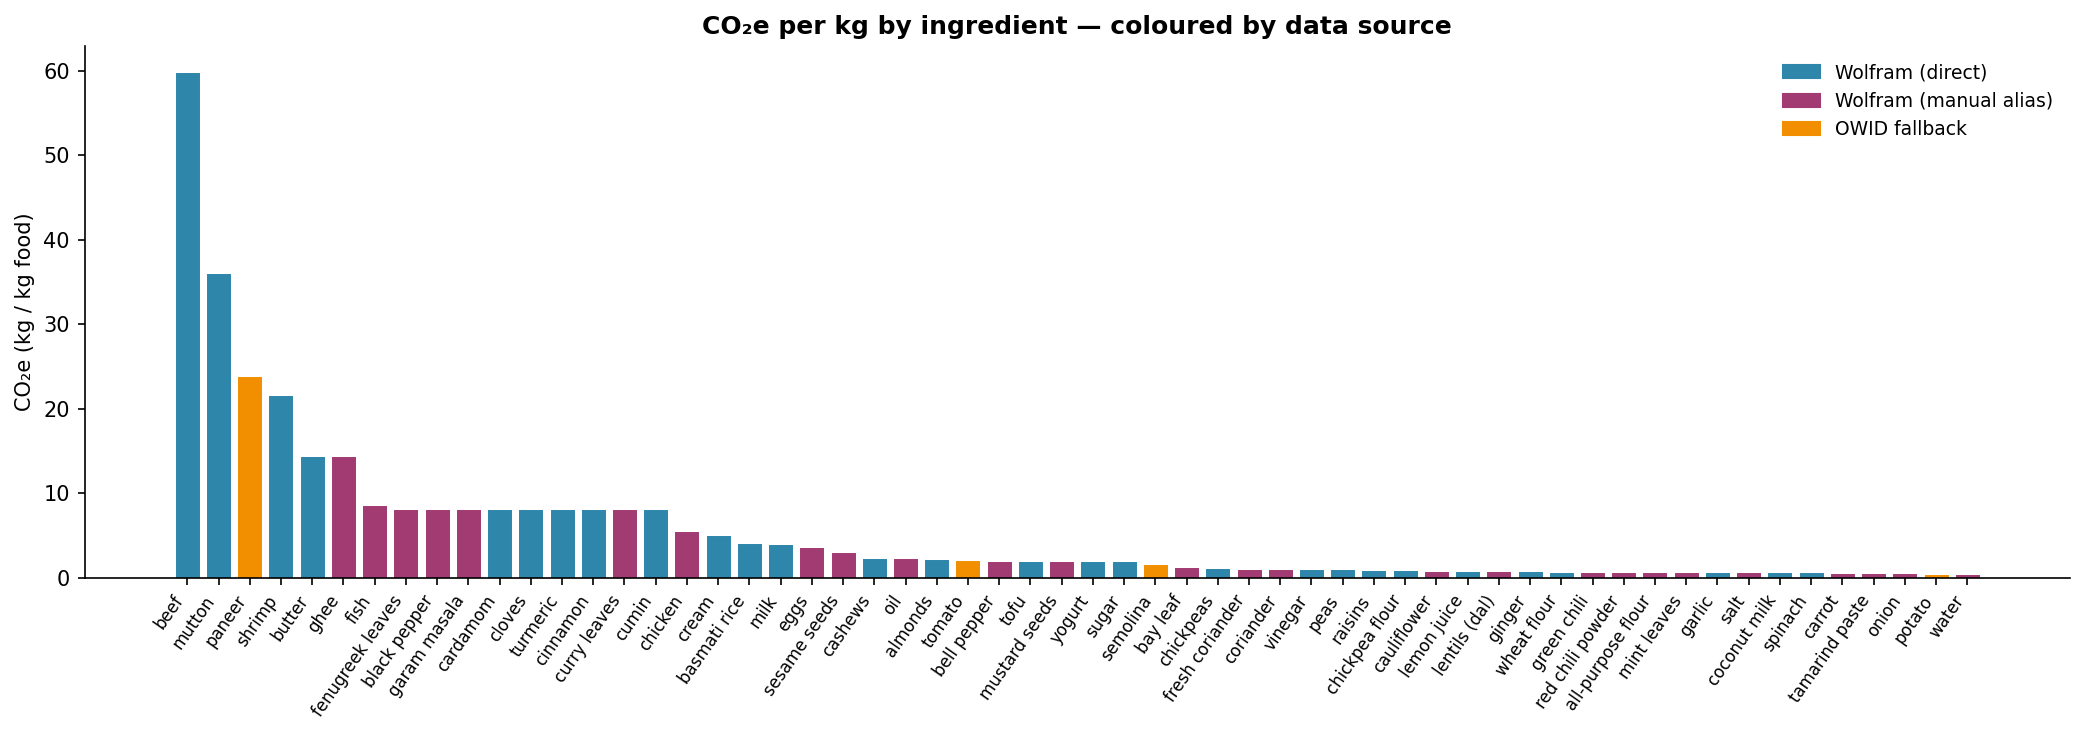

In [2]:
matched_df = source_df[source_df['source'] != 'Unmatched'].sort_values('co2_kg_per_kg', ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
bar_colors = [COLORS[s] for s in matched_df['source']]
bars = ax.bar(range(len(matched_df)), matched_df['co2_kg_per_kg'], color=bar_colors, edgecolor='white', linewidth=0.5)
ax.set_xticks(range(len(matched_df)))
ax.set_xticklabels(matched_df['ingredient'], rotation=55, ha='right', fontsize=8)
ax.set_ylabel('CO₂e (kg / kg food)')
ax.set_title('CO₂e per kg by ingredient — coloured by data source', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

legend_handles = [mpatches.Patch(color=COLORS[s], label=s)
                  for s in ['Wolfram (direct)', 'Wolfram (manual alias)', 'OWID fallback']]
ax.legend(handles=legend_handles, fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig('figures/04_ingredient_co2_by_source.png', bbox_inches='tight')
plt.show()


## 5 · Coverage Impact of Each Matching Layer

Without manual maps the majority of ingredients would have no CO₂e value. This chart shows the cumulative coverage gain — in unique ingredient names and in recipe-ingredient rows — as each layer is added.

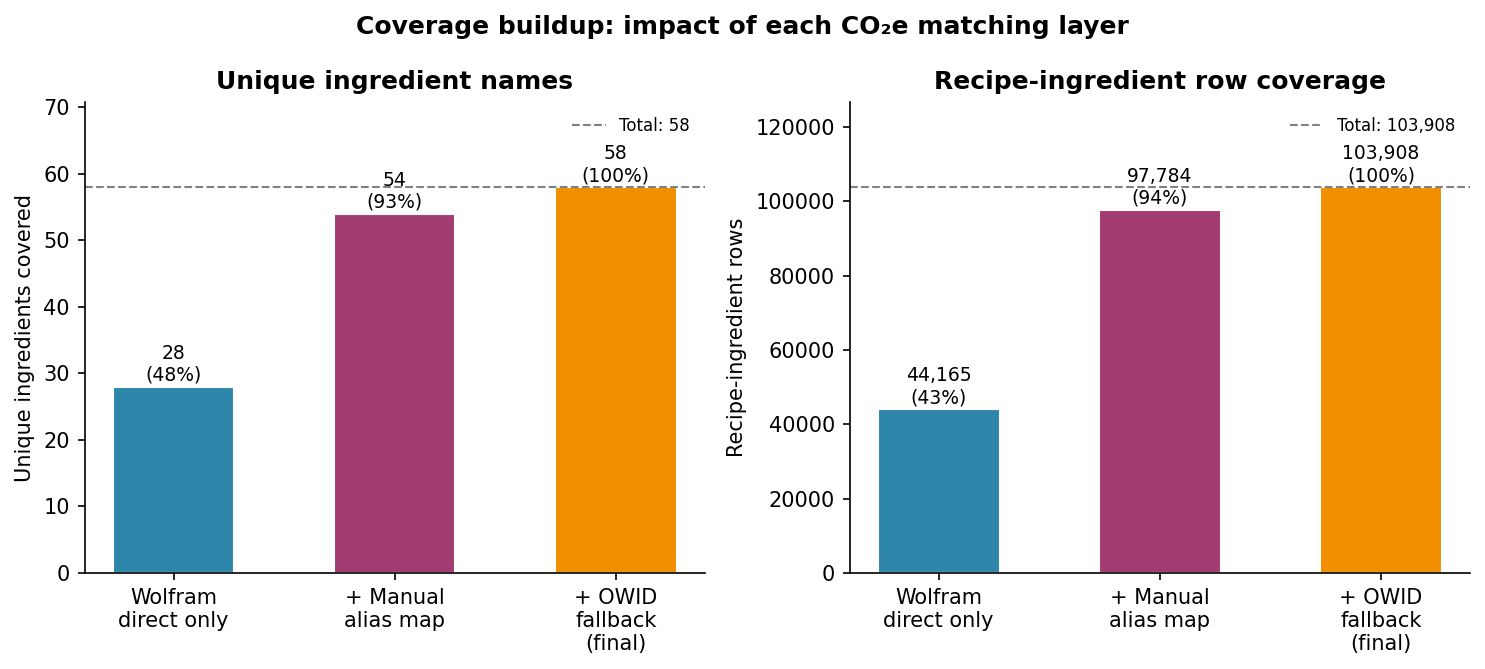

In [3]:

direct_ingrs = set(source_df.loc[source_df['source'] == 'Wolfram (direct)', 'ingredient'])
alias_ingrs  = set(source_df.loc[source_df['source'] == 'Wolfram (manual alias)', 'ingredient'])
owid_ingrs   = set(source_df.loc[source_df['source'] == 'OWID fallback', 'ingredient'])

freq_map = ingr_df['ingredient_lower'].value_counts()

def rows_for(ingr_set):
    return int(freq_map[freq_map.index.isin(ingr_set)].sum())

total_ingrs = len(source_df)
total_rows  = len(ingr_df)

scenarios = [
    ('Wolfram\ndirect only',         direct_ingrs,                             ),
    ('+ Manual\nalias map',          direct_ingrs | alias_ingrs,               ),
    ('+ OWID\nfallback\n(final)',    direct_ingrs | alias_ingrs | owid_ingrs,  ),
]

bar_colors = ['#2E86AB', '#A23B72', '#F18F01']

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, (get_val, ylabel, title) in zip(
    axes,
    [
        (lambda s: len(s),      'Unique ingredients covered', 'Unique ingredient names'),
        (lambda s: rows_for(s), 'Recipe-ingredient rows',     'Recipe-ingredient row coverage'),
    ],
):
    vals  = [get_val(s[1]) for s in scenarios]
    total = total_ingrs if 'names' in title else total_rows
    labels_x = [s[0] for s in scenarios]
    bars = ax.bar(labels_x, vals, color=bar_colors, edgecolor='white', width=0.55)
    ax.axhline(total, color='grey', linestyle='--', linewidth=1, label=f'Total: {total:,}')
    for bar, val in zip(bars, vals):
        pct = val / total * 100
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total * 0.015,
                f'{val:,}\n({pct:.0f}%)', ha='center', fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, total * 1.22)
    ax.legend(fontsize=8, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Coverage buildup: impact of each CO₂e matching layer', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/05_coverage_buildup.png', bbox_inches='tight')
plt.show()
